# Lista RK — Métodos de Runge-Kutta

Notebook estruturado para rodar no **Jupyter**, com:
- validação das funções contra exemplos do slide;
- resolução das questões da lista;
- funções genéricas reutilizáveis.


## Funções implementadas

- `euler(f, x0, y0, h, x_end)` — RK de primeira ordem (Euler);
- `heun(f, x0, y0, h, x_end)` — RK2 variante Heun;
- `midpoint(f, x0, y0, h, x_end)` — RK2 variante Ponto Médio;
- `ralston(f, x0, y0, h, x_end)` — RK2 variante Ralston;
- `rk3(f, x0, y0, h, x_end)` — RK de terceira ordem;
- `rk4(f, x0, y0, h, x_end)` — RK de quarta ordem clássico.

Todas aceitam `f(x, y)` escalar **ou** vetorial (sistemas de EDOs).
O estado inicial `y0` pode ser escalar ou array.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def euler(f, x0, y0, h, x_end):
    xs, ys = [x0], [np.atleast_1d(np.asarray(y0, float))]
    x, y = x0, np.atleast_1d(np.asarray(y0, float))
    while x < x_end - 1e-12:
        y = y + h * np.atleast_1d(f(x, y))
        x += h
        xs.append(x); ys.append(y.copy())
    return np.array(xs), np.array(ys)

def heun(f, x0, y0, h, x_end):
    xs, ys = [x0], [np.atleast_1d(np.asarray(y0, float))]
    x, y = x0, np.atleast_1d(np.asarray(y0, float))
    while x < x_end - 1e-12:
        k1 = np.atleast_1d(f(x, y))
        k2 = np.atleast_1d(f(x + h, y + h * k1))
        y = y + h * (k1 + k2) / 2; x += h
        xs.append(x); ys.append(y.copy())
    return np.array(xs), np.array(ys)

def midpoint(f, x0, y0, h, x_end):
    xs, ys = [x0], [np.atleast_1d(np.asarray(y0, float))]
    x, y = x0, np.atleast_1d(np.asarray(y0, float))
    while x < x_end - 1e-12:
        k1 = np.atleast_1d(f(x, y))
        k2 = np.atleast_1d(f(x + 0.5*h, y + 0.5*h * k1))
        y = y + h * k2; x += h
        xs.append(x); ys.append(y.copy())
    return np.array(xs), np.array(ys)

def ralston(f, x0, y0, h, x_end):
    xs, ys = [x0], [np.atleast_1d(np.asarray(y0, float))]
    x, y = x0, np.atleast_1d(np.asarray(y0, float))
    while x < x_end - 1e-12:
        k1 = np.atleast_1d(f(x, y))
        k2 = np.atleast_1d(f(x + 0.75*h, y + 0.75*h * k1))
        y = y + h * (k1/3 + 2*k2/3); x += h
        xs.append(x); ys.append(y.copy())
    return np.array(xs), np.array(ys)

def rk3(f, x0, y0, h, x_end):
    xs, ys = [x0], [np.atleast_1d(np.asarray(y0, float))]
    x, y = x0, np.atleast_1d(np.asarray(y0, float))
    while x < x_end - 1e-12:
        k1 = np.atleast_1d(f(x, y))
        k2 = np.atleast_1d(f(x + 0.5*h, y + 0.5*h * k1))
        k3 = np.atleast_1d(f(x + h,     y + h * (-k1 + 2*k2)))
        y = y + h * (k1 + 4*k2 + k3) / 6; x += h
        xs.append(x); ys.append(y.copy())
    return np.array(xs), np.array(ys)

def rk4(f, x0, y0, h, x_end):
    xs, ys = [x0], [np.atleast_1d(np.asarray(y0, float))]
    x, y = x0, np.atleast_1d(np.asarray(y0, float))
    while x < x_end - 1e-12:
        k1 = np.atleast_1d(f(x, y))
        k2 = np.atleast_1d(f(x + 0.5*h, y + 0.5*h * k1))
        k3 = np.atleast_1d(f(x + 0.5*h, y + 0.5*h * k2))
        k4 = np.atleast_1d(f(x + h,     y + h * k3))
        y = y + h * (k1 + 2*k2 + 2*k3 + k4) / 6; x += h
        xs.append(x); ys.append(y.copy())
    return np.array(xs), np.array(ys)


## Validação com exemplos do slide

Antes de usar na lista, cada função é conferida contra os resultados
calculados explicitamente no slide.


### Validação 1 — Euler (RK1), slide p. 11–13

EDO: $dy/dx = -2x^3 + 12x^2 - 20x + 8{,}5$,  $y(0)=1$, $h=0{,}5$, $x\in[0,1]$.

Slide fornece: $y_1=5{,}25$ e $y_2=5{,}875$. Solução exata: $y = -0{,}5x^4+4x^3-10x^2+8{,}5x+1$.


In [2]:
def f_slide(x, y): return np.array([-2*x**3 + 12*x**2 - 20*x + 8.5])
def y_exato_slide(x): return -0.5*x**4 + 4*x**3 - 10*x**2 + 8.5*x + 1

xs_e, ys_e = euler(f_slide, 0, [1.0], 0.5, 1.0)
print(f'y(0.5) Euler={ys_e[1,0]:.5f}  (slide: 5.25000)  Exato={y_exato_slide(0.5):.5f}')
print(f'y(1.0) Euler={ys_e[2,0]:.5f}  (slide: 5.87500)  Exato={y_exato_slide(1.0):.5f}')
ok = abs(ys_e[1,0]-5.25)<1e-9 and abs(ys_e[2,0]-5.875)<1e-9
print(f'Validação 1: {"OK" if ok else "ERRO"}')


y(0.5) Euler=5.25000  (slide: 5.25000)  Exato=3.21875
y(1.0) Euler=5.87500  (slide: 5.87500)  Exato=3.00000
Validação 1: OK


### Validação 2 — RK4, slide p. 23

Mesma EDO, $x=[0,5]$, $h=0{,}1$, $y(0)=1$. Espera-se erro de máquina contra a solução exata.


In [3]:
xs4, ys4 = rk4(f_slide, 0, [1.0], 0.1, 5.0)
erros4 = np.abs(ys4[:,0] - y_exato_slide(xs4))
print(f'Erro máximo RK4 vs solução exata: {erros4.max():.3e}')
print(f'y(5.0) RK4={ys4[-1,0]:.8f}  Exato={y_exato_slide(5.0):.8f}')
print(f'Validação 2: {"OK" if erros4.max()<1e-10 else "CHECAR"}')


Erro máximo RK4 vs solução exata: 1.137e-13
y(5.0) RK4=-19.00000000  Exato=-19.00000000
Validação 2: OK


### Validação 3 — PVI de 2ª ordem, slide p. 36

EDO: $y'' = 2y' - 3y + \cos x$,  $y(0)=3$, $y'(0)=8$, $x\in[0,3]$, $h=0{,}1$.

Substituição $w=y'$ produz o sistema: $y'=w$, $w'=2w-3y+\cos x$.

Solução exata analítica: $y = e^x\!\left(C_1\cos\!\sqrt{2}\,x + C_2\sin\!\sqrt{2}\,x\right) + \tfrac{\cos x - \sin x}{4}$,
com $C_1=\tfrac{11}{4}$ e $C_2=\tfrac{5{,}5}{\sqrt{2}}$.


In [4]:
sqrt2 = np.sqrt(2)
C1, C2 = 11/4, 5.5/sqrt2

def y_exato_2(x):
    return np.exp(x)*(C1*np.cos(sqrt2*x) + C2*np.sin(sqrt2*x)) + (np.cos(x)-np.sin(x))/4

def f_2ordem(x, u):
    return np.array([u[1], 2*u[1] - 3*u[0] + np.cos(x)])

xs3v, ys3v = rk4(f_2ordem, 0, [3.0, 8.0], 0.1, 3.0)
erros3v = np.abs(ys3v[:,0] - y_exato_2(xs3v))
print(f'y(0.1) RK4={ys3v[1,0]:.6f}  Exato={y_exato_2(0.1):.6f}  Err={erros3v[1]:.2e}')
print(f'y(1.0) RK4={ys3v[10,0]:.6f}  Exato={y_exato_2(1.0):.6f}  Err={erros3v[10]:.2e}')
print(f'y(3.0) RK4={ys3v[-1,0]:.6f}  Exato={y_exato_2(3.0):.6f}  Err={erros3v[-1]:.2e}')
print(f'Erro máximo: {erros3v.max():.3e}')
print(f'Validação 3: {"OK" if erros3v.max()<0.01 else "CHECAR"}')


y(0.1) RK4=3.838496  Exato=3.838491  Err=4.61e-06
y(1.0) RK4=11.532670  Exato=11.532731  Err=6.10e-05
y(3.0) RK4=-94.938564  Exato=-94.938888  Err=3.25e-04
Erro máximo: 1.020e-03
Validação 3: OK


## Questão 1

**Enunciado reescrito.** Circuito RL com resistor não-linear $R = 500 + 250I^2\,\Omega$,
$V_0=1000\,\text{V}$, $L=15\,\text{H}$. Chave fechada em $t=0$, $I(0)=0$.

$$\frac{dI}{dt} = \frac{V_0}{L} - \frac{R}{L}I$$

Resolver em $t\in[0;0{,}1]$ com $h=0{,}005$ usando as três variantes de RK2.
Traçar a corrente em função do tempo.


t(s)     Heun       PontoMédio  Ralston
0.000    0.000000   0.000000   0.000000
0.020    0.892862   0.897630   0.895359
0.040    1.132599   1.134130   1.133395
0.060    1.172547   1.172799   1.172678
0.080    1.178492   1.178529   1.178511
0.100    1.179361   1.179366   1.179364


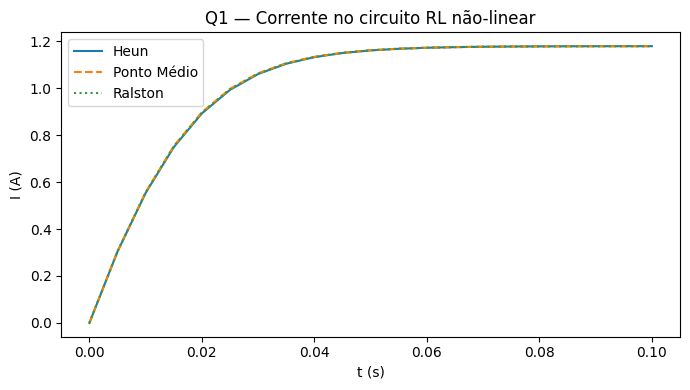

In [8]:
V0, L = 1000.0, 15.0
def f_q1(t, I): return np.array([(V0 - (500 + 250*I[0]**2)*I[0]) / L])

h1, t_end1 = 0.005, 0.1
t_h, I_h = heun    (f_q1, 0, [0.0], h1, t_end1)
t_m, I_m = midpoint(f_q1, 0, [0.0], h1, t_end1)
t_r, I_r = ralston (f_q1, 0, [0.0], h1, t_end1)

print('t(s)     Heun       PontoMédio  Ralston')
for i in range(0, len(t_h), 4):
    print(f'{t_h[i]:.3f}    {I_h[i,0]:.6f}   {I_m[i,0]:.6f}   {I_r[i,0]:.6f}')

plt.figure(figsize=(7,4))
plt.plot(t_h, I_h[:,0], label='Heun')
plt.plot(t_m, I_m[:,0], '--', label='Ponto Médio')
plt.plot(t_r, I_r[:,0], ':', label='Ralston')
plt.xlabel('t (s)'); plt.ylabel('I (A)')
plt.title('Q1 — Corrente no circuito RL não-linear')
plt.legend(); plt.tight_layout(); plt.show()


## Questão 2

**Enunciado reescrito.** PVI: $dy/dx = yx^2 - 1{,}1y$, $y(0)=1$, $x\in[0,2]$.

Solução exata: $y = e^{x^3/3 - 1{,}1x}$.

Aplicar RK de 1ª a 4ª ordem com $h=0{,}1$ e $h=0{,}01$. Calcular o erro de truncamento total.



h = 0.1
Método       Err máx         Err em x=2     
Euler        4.3578e-01      4.3578e-01     
Heun         5.5232e-03      5.5232e-03     
RK3          1.5408e-04      7.4177e-05     
RK4          3.0767e-05      3.0767e-05     

h = 0.01
Método       Err máx         Err em x=2     
Euler        5.3958e-02      5.3958e-02     
Heun         5.7834e-05      5.7834e-05     
RK3          1.7776e-07      6.6395e-08     
RK4          3.3833e-09      3.3833e-09     


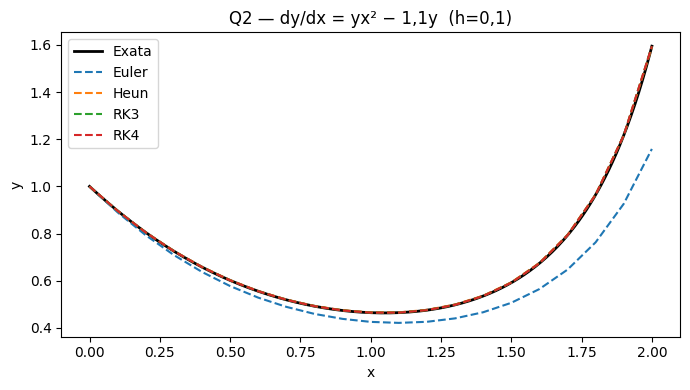

In [6]:
def f_q2(x, y): return np.array([y[0]*x**2 - 1.1*y[0]])
def y_exato_q2(x): return np.exp(x**3/3 - 1.1*x)

metodos = [('Euler', euler), ('Heun', heun), ('RK3', rk3), ('RK4', rk4)]

for h_val in [0.1, 0.01]:
    print(f'\nh = {h_val}')
    print(f'{"Método":<12} {"Err máx":<15} {"Err em x=2":<15}')
    for nome, func in metodos:
        xs2, ys2 = func(f_q2, 0, [1.0], h_val, 2.0)
        erros = np.abs(ys2[:,0] - y_exato_q2(xs2))
        print(f'{nome:<12} {erros.max():<15.4e} {erros[-1]:<15.4e}')

# gráfico para h=0.1
xs_ex = np.linspace(0, 2, 300)
plt.figure(figsize=(7,4))
plt.plot(xs_ex, y_exato_q2(xs_ex), 'k-', lw=2, label='Exata')
for nome, func in metodos:
    xs2, ys2 = func(f_q2, 0, [1.0], 0.1, 2.0)
    plt.plot(xs2, ys2[:,0], '--', label=nome)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q2 — dy/dx = yx² − 1,1y  (h=0,1)')
plt.legend(); plt.tight_layout(); plt.show()


## Questão 3

**Enunciado reescrito.** EDO: $dy/dx = yx - x^3$, $y(0)=1$, $x\in[0,8]$.

Solução exata: $y = (x^2+2) - e^{x^2/2}$.

Usar RK2 nas três variantes (Heun, Ponto Médio, Ralston) com $h \in \{0{,}5,\,0{,}2,\,0{,}05\}$.
Calcular o erro de truncamento total em cada caso.


h      Variante     Err abs x=8        Err rel x=8
0.5    Heun         7.8934e+13         9.9963e-01
0.5    PontoMédio   7.8943e+13         9.9975e-01
0.5    Ralston      7.8939e+13         9.9970e-01
0.2    Heun         7.4802e+13         9.4730e-01
0.2    PontoMédio   7.5334e+13         9.5405e-01
0.2    Ralston      7.5078e+13         9.5080e-01
0.05   Heun         2.2553e+13         2.8562e-01
0.05   PontoMédio   2.3447e+13         2.9694e-01
0.05   Ralston      2.3002e+13         2.9130e-01


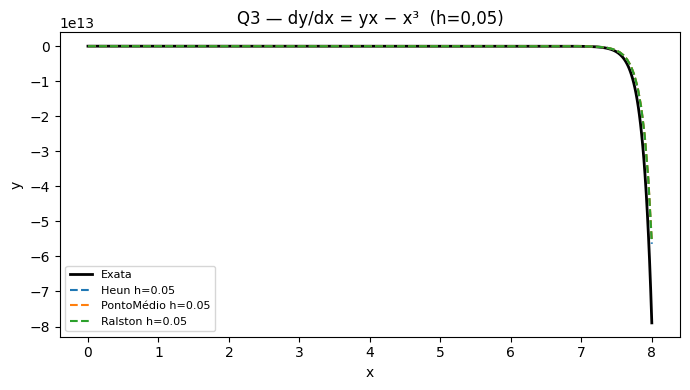

In [7]:
def f_q3(x, y): return np.array([y[0]*x - x**3])
def y_exato_q3(x): return (x**2 + 2) - np.exp(x**2/2)

# y_exato(8) ≈ -7.9e13 (dominado por -e^(x²/2)).
# Erros absolutos crescem com fator e^(x²/2) — qualquer perturbação inicial
# amplifica-se por e^(∫₀ˣ t dt). O erro RELATIVO é o indicador relevante aqui.

passos = [0.5, 0.2, 0.05]
variantes = [('Heun', heun), ('PontoMédio', midpoint), ('Ralston', ralston)]

print(f'{"h":<6} {"Variante":<12} {"Err abs x=8":<18} {"Err rel x=8"}')
for h_val in passos:
    for nome, func in variantes:
        xs3, ys3 = func(f_q3, 0, [1.0], h_val, 8.0)
        y_ex = y_exato_q3(xs3[-1])
        err_abs = abs(ys3[-1, 0] - y_ex)
        err_rel = err_abs / abs(y_ex)
        print(f'{h_val:<6} {nome:<12} {err_abs:<18.4e} {err_rel:.4e}')

plt.figure(figsize=(7, 4))
xs_ex3 = np.linspace(0, 8, 500)
plt.plot(xs_ex3, y_exato_q3(xs_ex3), 'k-', lw=2, label='Exata')
for nome, func in variantes:
    xs3, ys3 = func(f_q3, 0, [1.0], 0.05, 8.0)
    plt.plot(xs3, ys3[:, 0], '--', label=f'{nome} h=0.05')
plt.xlabel('x'); plt.ylabel('y')
plt.title('Q3 — dy/dx = yx − x³  (h=0,05)')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


## Questão 4

**Enunciado reescrito.** Tanque esférico ($R=4\,\text{m}$) com furo no fundo ($r=0{,}02\,\text{m}$).

$$\frac{dh}{dt} = -\frac{r^2\sqrt{2gh}}{2hR - h^2}$$

$g=9{,}81\,\text{m/s}^2$, $h(0)=6\,\text{m}$. Determinar o tempo para $h$ atingir $0{,}5\,\text{m}$.
Comparar RK3 e RK4.


RK3: tempo para h=0.5 m → t ≈ 23310 s  (388.5 min)
RK4: tempo para h=0.5 m → t ≈ 23310 s  (388.5 min)


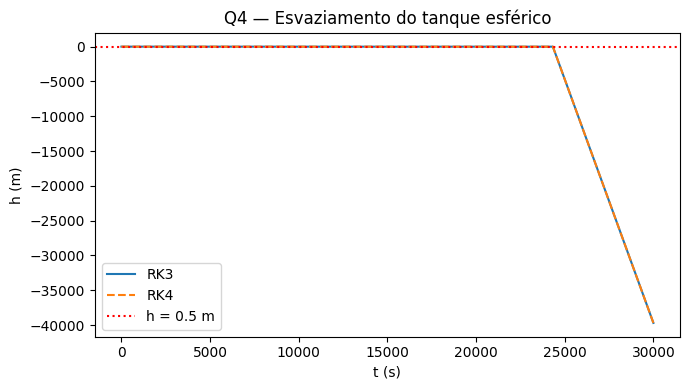

In [8]:
R_tank, r_hole, g = 4.0, 0.02, 9.81
h_stop = 0.5

def f_q4(t, h):
    hv = max(h[0], 1e-9)
    return np.array([-r_hole**2 * np.sqrt(2 * g * hv) / (2 * hv * R_tank - hv**2)])

# Estimativa prévia: drenagem de h=6 a h=0.5 leva ~23000 s
h_step = 10.0
t_end_q4 = 30000.0

ts3, hs3 = rk3(f_q4, 0, [6.0], h_step, t_end_q4)
ts4, hs4 = rk4(f_q4, 0, [6.0], h_step, t_end_q4)

idx3 = np.where(hs3[:, 0] <= h_stop)[0]
idx4 = np.where(hs4[:, 0] <= h_stop)[0]
t_rk3 = ts3[idx3[0]] if len(idx3) else float('nan')
t_rk4 = ts4[idx4[0]] if len(idx4) else float('nan')
print(f'RK3: tempo para h=0.5 m → t ≈ {t_rk3:.0f} s  ({t_rk3/60:.1f} min)')
print(f'RK4: tempo para h=0.5 m → t ≈ {t_rk4:.0f} s  ({t_rk4/60:.1f} min)')

plt.figure(figsize=(7, 4))
plt.plot(ts3, hs3[:, 0], label='RK3')
plt.plot(ts4, hs4[:, 0], '--', label='RK4')
plt.axhline(h_stop, color='r', ls=':', label=f'h = {h_stop} m')
plt.xlabel('t (s)'); plt.ylabel('h (m)')
plt.title('Q4 — Esvaziamento do tanque esférico')
plt.legend(); plt.tight_layout(); plt.show()


## Questão 5

**Enunciado reescrito.** Circuito RLC com resistor não-linear
$R = R_0 + R_1 I^2$, $R_0=500\,\Omega$, $R_1=250\,\Omega/\text{A}^2$,
$L=15\,\text{H}$, $C=4{,}2\,\mu\text{F}$, $V_0=1000\,\text{V}$.

$$\frac{d^2Q}{dt^2} + \frac{R_0}{L}\frac{dQ}{dt} + \frac{R_1}{L}\left(\frac{dQ}{dt}\right)^3 + \frac{Q}{LC} = \frac{V_0}{L}$$

$Q(0)=0$, $I(0)=\dot{Q}(0)=0$.

Substituição $u_1=Q$, $u_2=\dot{Q}=I$:
$u_1'=u_2$, $u_2'=V_0/L - (R_0/L)u_2 - (R_1/L)u_2^3 - u_1/(LC)$.

Resolver com RK4. Traçar $Q(t)$ e $I(t)$.


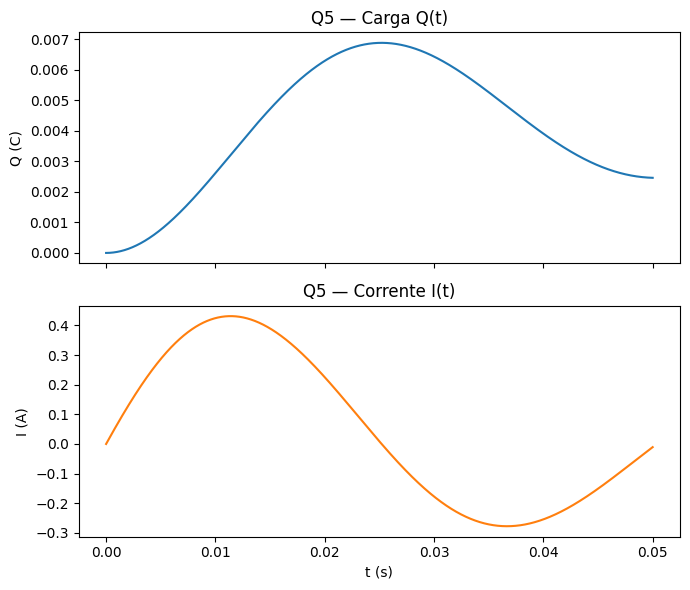

Q máx = 6.8815e-03 C  em t = 2.5210e-02 s
I máx = 0.4312 A  em t = 1.1390e-02 s


In [9]:
R0, R1, L5, C5, V05 = 500.0, 250.0, 15.0, 4.2e-6, 1000.0

def f_q5(t, u):
    Q, I = u[0], u[1]
    dQdt = I
    dIdt = V05/L5 - (R0/L5)*I - (R1/L5)*I**3 - Q/(L5*C5)
    return np.array([dQdt, dIdt])

ts5, us5 = rk4(f_q5, 0, [0.0, 0.0], 1e-5, 0.05)
Q5 = us5[:,0]; I5 = us5[:,1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax1.plot(ts5, Q5); ax1.set_ylabel('Q (C)'); ax1.set_title('Q5 — Carga Q(t)')
ax2.plot(ts5, I5, color='tab:orange'); ax2.set_ylabel('I (A)'); ax2.set_xlabel('t (s)')
ax2.set_title('Q5 — Corrente I(t)')
plt.tight_layout(); plt.show()

print(f'Q máx = {Q5.max():.4e} C  em t = {ts5[np.argmax(Q5)]:.4e} s')
print(f'I máx = {I5.max():.4f} A  em t = {ts5[np.argmax(I5)]:.4e} s')


## Questão 6

**Enunciado reescrito.** Sistema massa-mola forçado:

$$\frac{d^2x}{dt^2} = -\frac{k}{m}x + \frac{F_0}{m}\cos\omega t$$

$m=2\,\text{kg}$, $k=800\,\text{N/m}$, $F_0=50\,\text{N}$, $\omega=3\,\text{rad/s}$.
C.I.: $x(0)=0{,}1\,\text{m}$, $x'(0)=0{,}1\,\text{m/s}$. Resolver em $t\in[0,10]\,\text{s}$, $h=0{,}01\,\text{s}$.

Substituição: $v=x'$. Sistema: $x'=v$, $v'=-kx/m + (F_0/m)\cos\omega t$.


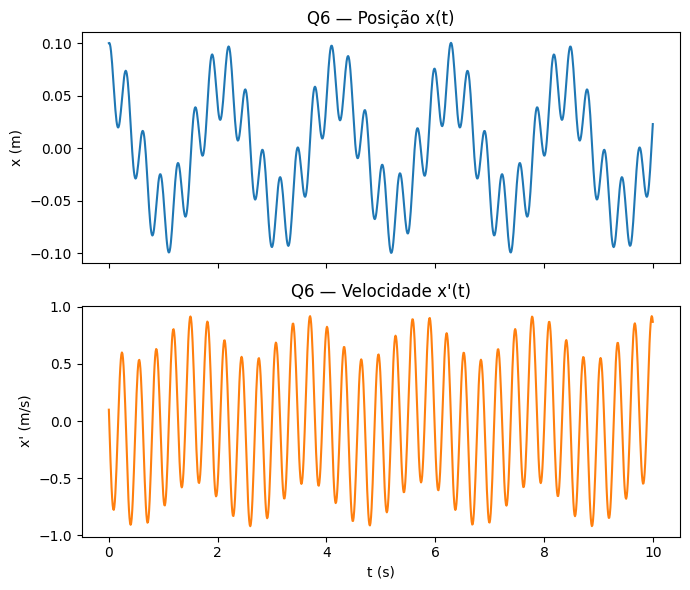

Frequência natural: ωₙ = 20.00 rad/s
Frequência forçada: ω  = 3.00 rad/s  (longe da ressonância)
Amplitude máx de x: 0.1003 m


In [10]:
m, k6, F0, om = 2.0, 800.0, 50.0, 3.0

def f_q6(t, u):
    x, v = u[0], u[1]
    return np.array([v, -k6/m*x + F0/m*np.cos(om*t)])

ts6, us6 = rk4(f_q6, 0, [0.1, 0.1], 0.01, 10.0)
x6 = us6[:,0]; v6 = us6[:,1]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True)
ax1.plot(ts6, x6); ax1.set_ylabel('x (m)'); ax1.set_title("Q6 — Posição x(t)")
ax2.plot(ts6, v6, color='tab:orange'); ax2.set_ylabel("x' (m/s)")
ax2.set_xlabel('t (s)'); ax2.set_title("Q6 — Velocidade x'(t)")
plt.tight_layout(); plt.show()

wn = np.sqrt(k6/m)
print(f'Frequência natural: ωₙ = {wn:.2f} rad/s')
print(f'Frequência forçada: ω  = {om:.2f} rad/s  (longe da ressonância)')
print(f'Amplitude máx de x: {np.abs(x6).max():.4f} m')
